# Experiment 0: verify the measurement pipeline

The zero-learning-rate controls exercise loading, forward/backward computation, optimizer plumbing, monitoring, saving and reloading while model weights must remain unchanged. There are 16 controls: four bases × two adaptation modes × two tasks, on one dataset partition.

A successful process exit is insufficient. Require the exact saved-state audit and per-dataset monitoring parity. These controls cannot validate positive-learning-rate optimization, long-run stability, recovery or final benchmark inference; those require the subsequent checks.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
REPO = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'pyproject.toml').is_file())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from IPython.display import display
from src.visualize import style
from src.visualize.figures import FigureSaver
from src.visualize import campaign as cp
from src.data.dataset_names import display_frame
from src.visualize.inputs import analysis_root
style.apply()
sink = FigureSaver('experiment0/01_null_controls')
report = cp.NotebookReport('Experiment 0: verify the measurement pipeline')


## 1. Planned and recorded controls

The config supplies the denominator, so absent trials appear as pending. An external analysis folder, if configured, is read only.

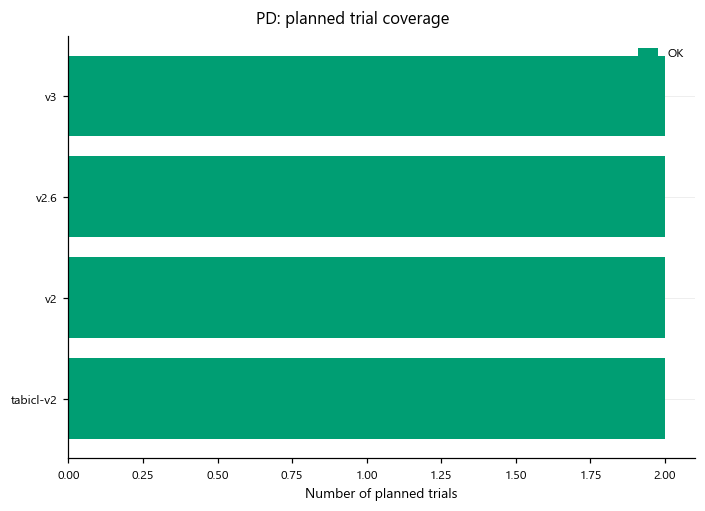

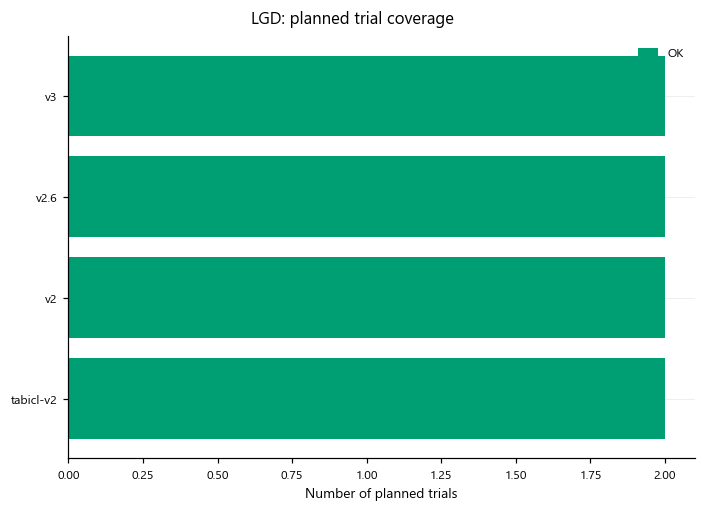

In [2]:
controls = [cp.load_campaign(0, track, 'null') for track in ('pd','lgd')]
for control in controls:
    cp.show(sink, cp.plot_coverage(control))
report.add('1. Control coverage', '\n\n'.join(cp.coverage_summary(c) for c in controls))

## 2. Saved-checkpoint audits

These results come from completed CPU audit reports. The canonical model and inference buffers must match, and monitoring must match for every observed dataset. A missing audit is not a pass.

,track,base,frozen,weight_equal,monitor_equal,updates,audit_passed
0,pd,v2,False,True,True,2,True
1,pd,v2,True,True,True,2,True
2,pd,v2.6,False,True,True,2,True
3,pd,v2.6,True,True,True,2,True
4,pd,v3,False,True,True,2,True
5,pd,v3,True,True,True,2,True
6,pd,tabicl-v2,False,True,True,2,True
7,pd,tabicl-v2,True,True,True,2,True
8,lgd,v2,False,True,True,2,True
9,lgd,v2,True,True,True,2,True


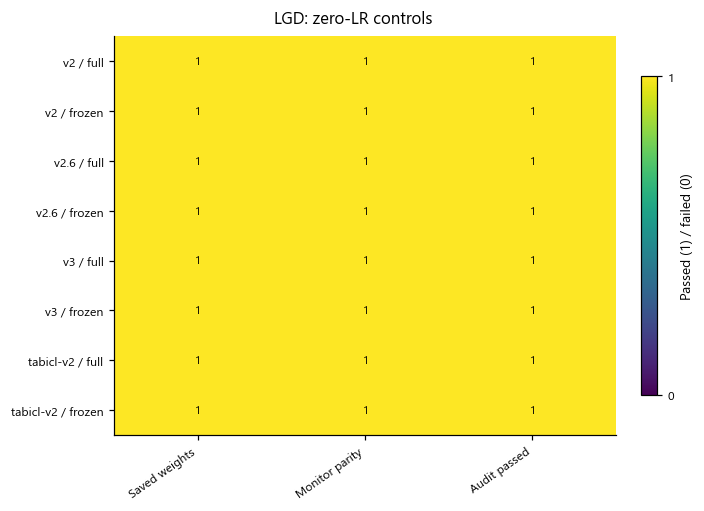

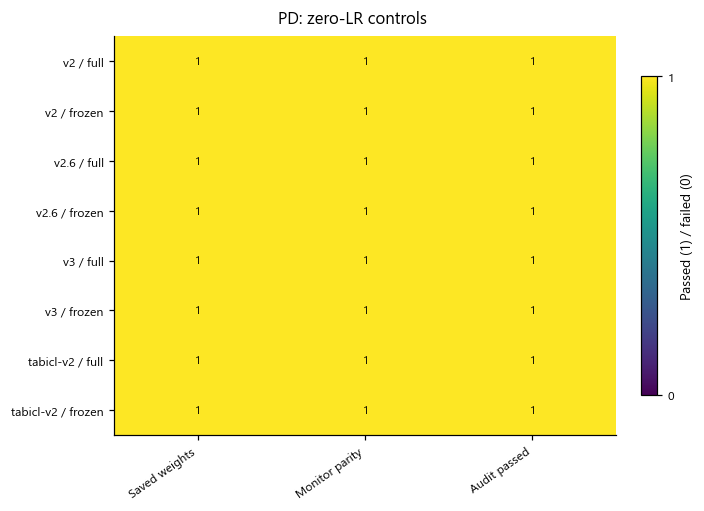

In [3]:
audits = cp.null_audits(controls)
display(audits)
cp.show(sink, cp.plot_null_audits(audits))
report.add('2. Saved-state audits', audits.to_string(index=False) if len(audits) else 'No completed audit reports in the selected analysis source.')

## 3. Monitor invariance

Show the largest absolute dataset effect in each control, separately on training and held-out tables. The audit checks unrounded values; this figure makes departures from zero easy to locate.

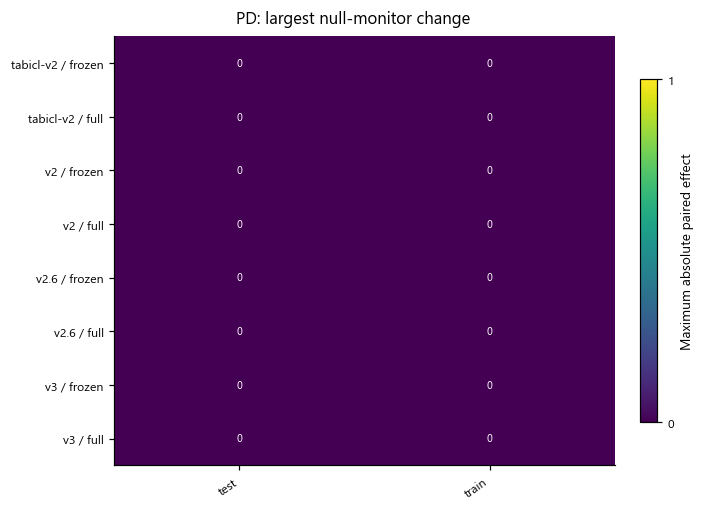

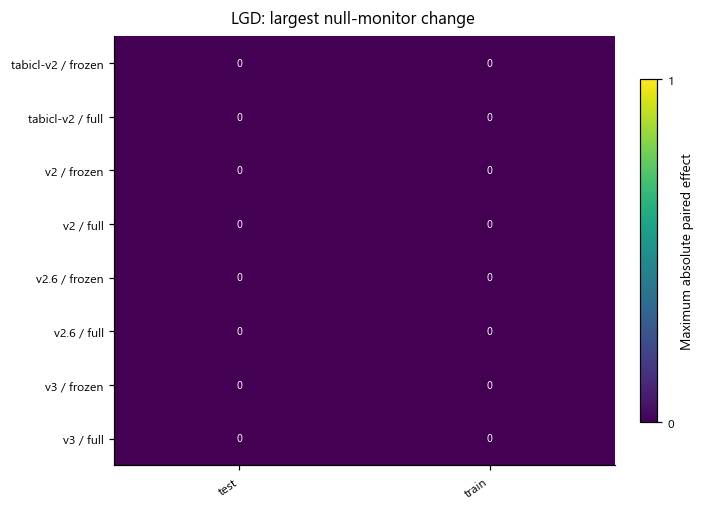

In [4]:
for control in controls:
    cp.show(sink, cp.plot_null_monitor(control))
report.add('3. Monitor invariance', '\n\n'.join(c.track.upper() + '\n' + cp.effect_summary(cp.endpoint_effects(c)) for c in controls))

## 4. What is still untested?

Before the main experiment, verify positive-LR behavior and interrupted/resumed execution on VSC. Then use the short and budget pilots to set resource requests and the training horizon. Two-update null timings are not production walltime estimates.

In [5]:
report.add('4. Remaining gates', 'Saved-state equality is separate from positive-LR correctness. Next: positive-LR/recovery checks, short timing pilots, budget pilots, then settle the main horizon. No jobs are submitted by this notebook.')

## Summary

The following text repeats the sections in order. It is included verbatim in `All_Results.md`.

In [6]:
print(report.summary(sink))

Experiment 0: verify the measurement pipeline

1. Control coverage
Run cpt_null_v4_check3; PD; 8 planned trials; target 2 successful updates.
status
OK    8
16 trajectory records; 0 benchmark fold records.

Run cpt_null_v4_check3; LGD; 8 planned trials; target 2 successful updates.
status
OK    8
16 trajectory records; 0 benchmark fold records.

2. Saved-state audits
track      base  frozen  weight_equal  monitor_equal  updates  audit_passed
   pd        v2   False          True           True        2          True
   pd        v2    True          True           True        2          True
   pd      v2.6   False          True           True        2          True
   pd      v2.6    True          True           True        2          True
   pd        v3   False          True           True        2          True
   pd        v3    True          True           True        2          True
   pd tabicl-v2   False          True           True        2          True
   pd tabicl-v2    Tru